# Анализ SFT-датасета Orbit Wars — сколько кораблей шлют «от текущей возможности»

**Зачем.** Решаем, как устроить «голову числа кораблей» и подходит ли
`data/sft.jsonl` под обучение. Главная метрика — **доля гарнизона источника**,
которую эксперт отправляет за один залп: `ns / garrison(from_id)`.

**Критичная оговорка по формату.** В реплеях `kaggle_environments`
`steps[t].observation` сохраняется **после** применения `action[t]` (корабли
уже улетели, продакшен начислен). Значит ход `moves[t]` принят по состоянию
`obs[t-1]`, а не `obs[t]`. Парсер (`dataprep/legacy/replay_parser.py`) спаривает obs и
moves внутри одного шага → в датасете **вход и таргет сдвинуты на кадр**.
Шаг 1 это проверяет эмпирически, дальше доля считается уже с коррекцией
(ход шага `t` сверяется с гарнизоном шага `t-1`).

In [ ]:
# --- конфиг и импорты -------------------------------------------------------
%matplotlib inline
import json, math, time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

PATH = "../data/sft.jsonl"   # ноутбук лежит в notebooks/, датасет — в data/
LIMIT = None                 # None = весь файл; число = первые N строк (быстрый прогон)
INFER_TARGET = True          # инференс типа цели по углу залпа (чуть дороже)
ANGLE_TOL = 0.6              # ~34°: допуск сопоставления угла хода и направления на планету
BUCKETS = np.array([0.25, 0.5, 0.75, 1.0])  # кандидаты-бакеты для классификатора доли

plt.rcParams["figure.dpi"] = 110

In [2]:
# --- один стриминговый проход по 2.2 ГБ (плоская память) --------------------
# Записи одного эпизода идут подряд, поэтому гарнизон шага t-1 держим в prev[(ep,pl)].
prev = {}                       # (episode, player) -> (step, gar)  — состояние прошлого шага
nm_hist = Counter()             # гистограмма «ходов за шаг»
n_rec = n_hold = 0
naive_over = naive_tot = 0      # ns > гарнизона ТОГО ЖЕ obs (наивное спаривание)
cor_over = 0                    # ns > гарнизона шага t-1 (после коррекции; ожидаем 0)
fr, absn, garr, tgt = [], [], [], []   # доля, абсолют, гарнизон источника, тип цели

def ang_dist(a, b):
    # модуль угловой разницы, приведённый к [0, pi]
    return abs((a - b + math.pi) % (2 * math.pi) - math.pi)

t0 = time.time()
with open(PATH) as f:
    for i, line in enumerate(f):
        if LIMIT and i >= LIMIT:
            break
        d = json.loads(line)
        ep, pl, st = d["episode"], d["player"], d["step"]
        moves = d.get("moves") or []
        # gar: planet_id -> (ships, owner, x, y) на ЭТОМ шаге
        gar = {p[0]: (p[5], p[1], p[2], p[3]) for p in (d["obs"]["planets"] or [])}
        n_rec += 1
        nm_hist[len(moves)] += 1
        if not moves:
            n_hold += 1

        # (1) наивно: ходы текущего шага против гарнизона этого же obs
        for mv in moves:
            src = gar.get(int(mv[0]))
            if src and src[0] > 0:
                naive_tot += 1
                if float(mv[2]) > src[0]:
                    naive_over += 1

        # (2) коррекция: ходы текущего шага против гарнизона ПРЕДЫДУЩЕГО шага
        pv = prev.get((ep, pl))
        if pv and pv[0] == st - 1:
            pgar = pv[1]
            for mv in moves:
                fid, ang, ns = int(mv[0]), float(mv[1]), float(mv[2])
                src = pgar.get(fid)
                if not src or src[0] <= 0:
                    continue
                if ns > src[0]:
                    cor_over += 1
                fr.append(ns / src[0]); absn.append(ns); garr.append(src[0])
                if INFER_TARGET:                       # цель = планета, лучше совпавшая с углом
                    sx, sy = src[2], src[3]
                    best, bd = None, 9.9
                    for pid, (ps, po, px, py) in pgar.items():
                        if pid == fid:
                            continue
                        da = ang_dist(ang, math.atan2(py - sy, px - sx))
                        if da < bd:
                            bd, best = da, po
                    if best is not None and bd < ANGLE_TOL:
                        tgt.append(0 if best == pl else (2 if best == -1 else 1))  # 0 своя,1 враг,2 нейтрал
                    else:
                        tgt.append(-1)
        prev[(ep, pl)] = (st, gar)

fr = np.array(fr); absn = np.array(absn); garr = np.array(garr); tgt = np.array(tgt)
print(f"строк: {n_rec:,}  |  время: {time.time()-t0:.1f}s  |  выровненных ходов: {len(fr):,}")
print(f"hold-rate (шагов без хода): {n_hold/n_rec:.1%}")

строк: 309,442  |  время: 161.3s  |  выровненных ходов: 496,309
hold-rate (шагов без хода): 52.0%


## Шаг 1 — целостность данных: сдвиг obs↔action на кадр

Если спаривать `moves[t]` с гарнизоном из того же `obs[t]` (как в текущем
датасете), огромная доля ходов «отправляет больше, чем стоит на планете» — что
по правилам невозможно. После коррекции (сверка с гарнизоном `t-1`) нарушений
**ровно ноль**. Это доказывает сдвиг и правильность фикса.

наивно   (obs того же шага): 281,077/495,092 = 56.8% ходов 'ns > гарнизон'
исправлено (obs шага t-1)  : 11/496,309 = 0.0% ходов 'ns > гарнизон'


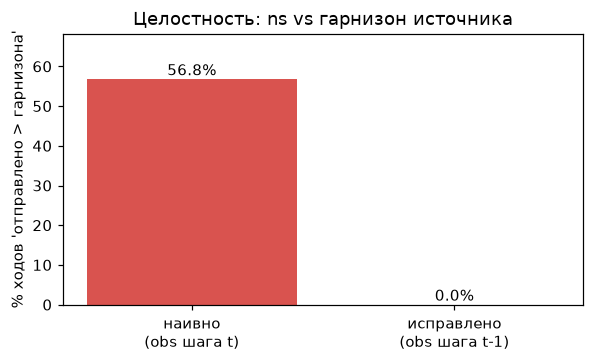

In [3]:
naive_pct = naive_over / max(naive_tot, 1) * 100
cor_pct   = cor_over   / max(len(fr), 1) * 100
print(f"наивно   (obs того же шага): {naive_over:,}/{naive_tot:,} = {naive_pct:.1f}% ходов 'ns > гарнизон'")
print(f"исправлено (obs шага t-1)  : {cor_over:,}/{len(fr):,} = {cor_pct:.1f}% ходов 'ns > гарнизон'")

plt.figure(figsize=(5.5, 3.4))
bars = plt.bar(["наивно\n(obs шага t)", "исправлено\n(obs шага t-1)"],
               [naive_pct, cor_pct], color=["#d9534f", "#5cb85c"])
plt.ylabel("% ходов 'отправлено > гарнизона'")
plt.title("Целостность: ns vs гарнизон источника")
for b, v in zip(bars, [naive_pct, cor_pct]):
    plt.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}%", ha="center")
plt.ylim(0, max(naive_pct, 5) * 1.2)
plt.tight_layout(); plt.show()

## Шаг 2 — доля гарнизона, отправляемая за залп

Главный график для дизайна головы. Видно резкий спайк у **1.0** (шлют всё) и
небольшую вторичную моду у **0.5**.

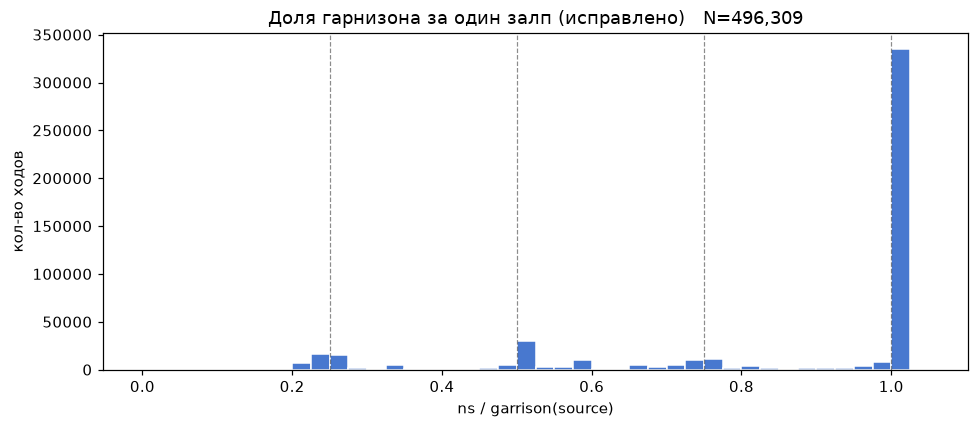

  масса в [0.00, 0.10) (~0): 0.2%
  масса в [0.20, 0.30) (≈0.25): 8.0%
  масса в [0.45, 0.55) (≈0.50): 7.5%
  масса в [0.70, 0.80) (≈0.75): 5.7%
  масса в [0.95, 1.00) (≈1.00): 69.7%
  ровно 100%: 67.5%   |   <=50%: 16.1%
  p5  = 0.248
  p10 = 0.393
  p25 = 0.748
  p50 = 1.000
  p75 = 1.000
  p90 = 1.000


In [4]:
clip = np.clip(fr, 0, 1.05)
plt.figure(figsize=(9, 4))
plt.hist(clip, bins=np.arange(0, 1.075, 0.025), color="#4878CF", edgecolor="white")
for b in BUCKETS:
    plt.axvline(b, color="k", ls="--", lw=0.8, alpha=0.45)
plt.title(f"Доля гарнизона за один залп (исправлено)   N={len(fr):,}")
plt.xlabel("ns / garrison(source)"); plt.ylabel("кол-во ходов")
plt.tight_layout(); plt.show()

for lo, hi, name in [(0.0, 0.1, "~0"), (0.2, 0.3, "≈0.25"), (0.45, 0.55, "≈0.50"),
                     (0.7, 0.8, "≈0.75"), (0.95, 1.0001, "≈1.00")]:
    print(f"  масса в [{lo:.2f}, {hi:.2f}) ({name}): {((fr >= lo) & (fr < hi)).mean():.1%}")
print(f"  ровно 100%: {(fr >= 0.999).mean():.1%}   |   <=50%: {(fr <= 0.5).mean():.1%}")
for q in (5, 10, 25, 50, 75, 90):
    print(f"  p{q:<2d} = {np.percentile(fr, q):.3f}")

## Шаг 2b — ляжет ли это в бакет-классификатор?

Квантуем долю в 4 бакета `{25, 50, 75, 100}%` и смотрим распределение и ошибку
квантования. Маленькая ошибка ⇒ классификатор по долям воспроизводит экспертов
почти без потерь.

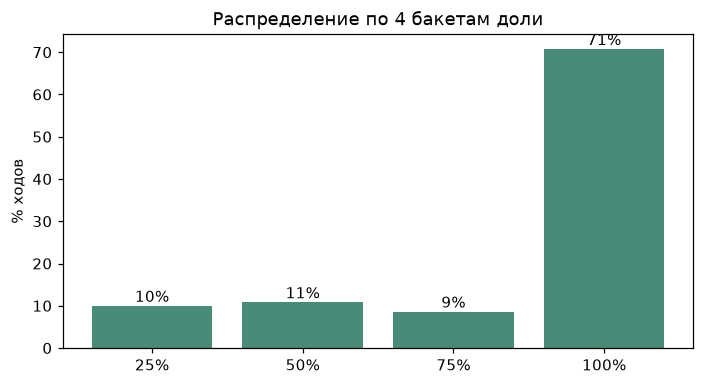

|ошибка квантования|: mean=0.011  p90=0.050
доля ходов в пределах ±0.05 от ближайшего бакета: 90.8%


In [5]:
snap = np.abs(fr[:, None] - BUCKETS[None, :]).argmin(1)
err = np.abs(fr - BUCKETS[snap])
shares = [(snap == i).mean() for i in range(len(BUCKETS))]

plt.figure(figsize=(6.5, 3.6))
bars = plt.bar([f"{int(b*100)}%" for b in BUCKETS], [s*100 for s in shares], color="#488b78")
for b, s in zip(bars, shares):
    plt.text(b.get_x() + b.get_width()/2, s*100 + 1, f"{s:.0%}", ha="center")
plt.ylabel("% ходов"); plt.title("Распределение по 4 бакетам доли")
plt.tight_layout(); plt.show()

print(f"|ошибка квантования|: mean={err.mean():.3f}  p90={np.percentile(err,90):.3f}")
print(f"доля ходов в пределах ±0.05 от ближайшего бакета: {(err <= 0.05).mean():.1%}")

## Шаг 3 — абсолютные числа и гарнизон источника

Абсолют гуляет очень широко (десятки–сотни), поэтому регрессия именно абсолюта
требовала бы лог-нормировки и всё равно ловила бы мультимодальность. Доля —
авто-нормирована.

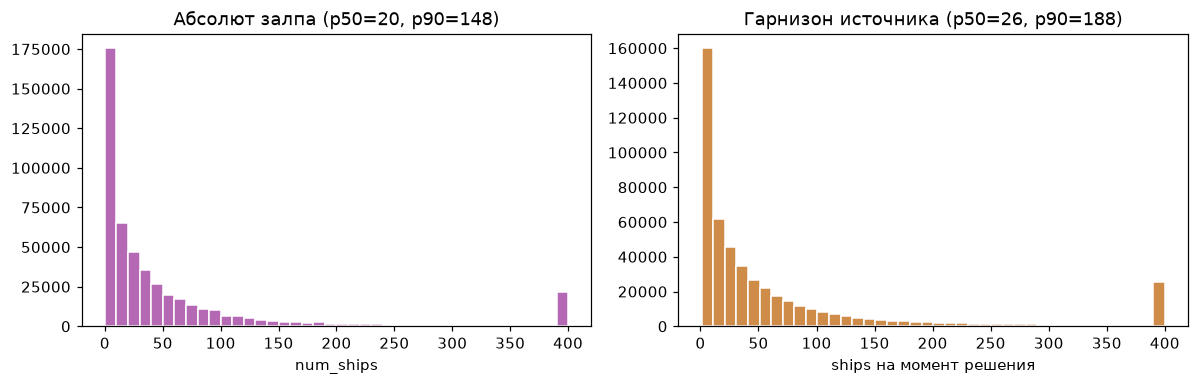

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(np.clip(absn, 0, 400), bins=40, color="#b569b5", edgecolor="white")
ax[0].set_title(f"Абсолют залпа (p50={np.percentile(absn,50):.0f}, p90={np.percentile(absn,90):.0f})")
ax[0].set_xlabel("num_ships")
ax[1].hist(np.clip(garr, 0, 400), bins=40, color="#cf8b48", edgecolor="white")
ax[1].set_title(f"Гарнизон источника (p50={np.percentile(garr,50):.0f}, p90={np.percentile(garr,90):.0f})")
ax[1].set_xlabel("ships на момент решения")
plt.tight_layout(); plt.show()

## Шаг 4 — доля по типу цели (приближённо, по углу)

Цель восстановлена по углу залпа (ближайшая по направлению планета). Если даже
**атаки на врага** шлют медиану ~100%, значит эксперты НЕ считают «ровно сколько
нужно для захвата» — они кидают всё. Это важно для выбора между имитацией и
эвристикой.

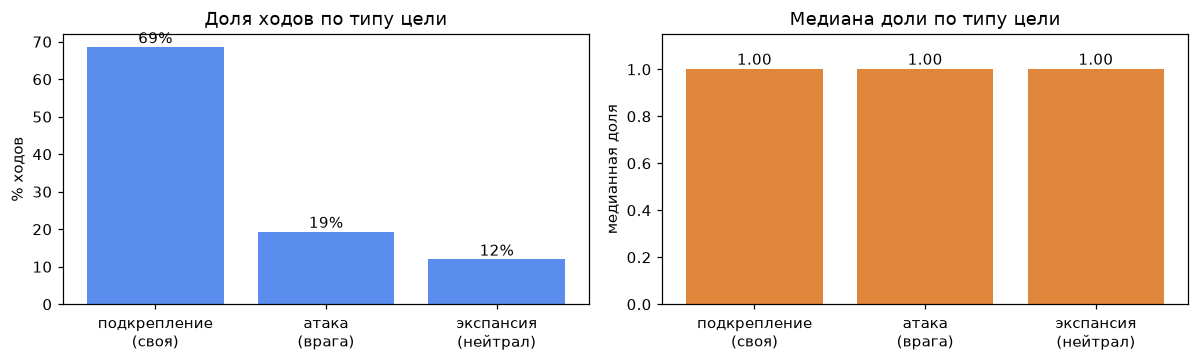

unknown (угол не сматчил планету): 0.0%


In [7]:
if INFER_TARGET and (tgt >= 0).any():
    names = {0: "подкрепление\n(своя)", 1: "атака\n(врага)", 2: "экспансия\n(нейтрал)"}
    ks = [0, 1, 2]
    shares = [(tgt == k).mean() for k in ks]
    medf = [np.median(fr[tgt == k]) if (tgt == k).any() else 0 for k in ks]

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    b0 = ax[0].bar([names[k] for k in ks], [s*100 for s in shares], color="#5b8def")
    for b, s in zip(b0, shares):
        ax[0].text(b.get_x()+b.get_width()/2, s*100+1, f"{s:.0%}", ha="center")
    ax[0].set_ylabel("% ходов"); ax[0].set_title("Доля ходов по типу цели")
    b1 = ax[1].bar([names[k] for k in ks], medf, color="#e0863a")
    for b, m in zip(b1, medf):
        ax[1].text(b.get_x()+b.get_width()/2, m+0.02, f"{m:.2f}", ha="center")
    ax[1].set_ylim(0, 1.15); ax[1].set_ylabel("медианная доля")
    ax[1].set_title("Медиана доли по типу цели")
    plt.tight_layout(); plt.show()
    print("unknown (угол не сматчил планету):", f"{(tgt == -1).mean():.1%}")
else:
    print("INFER_TARGET выключен")

## Шаг 5 — режим хода: hold vs действие, ходов за шаг

Половина шагов победителя — «ничего не делаю». Значит решение о числе кораблей
вторично по отношению к решению «ходить ли вообще»: нужна отдельная гейт-голова
(или явный класс `hold`).

hold-rate: 52.0%


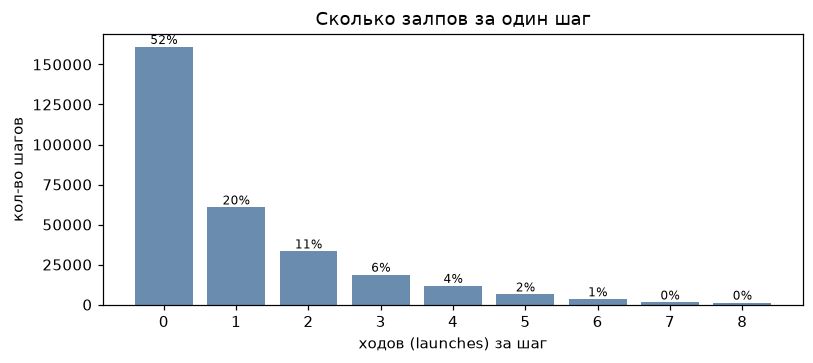

In [8]:
print(f"hold-rate: {n_hold/n_rec:.1%}")
xs = sorted(nm_hist)[:9]
plt.figure(figsize=(7.5, 3.4))
bars = plt.bar([str(x) for x in xs], [nm_hist[x] for x in xs], color="#6a8caf")
for b, x in zip(bars, xs):
    plt.text(b.get_x()+b.get_width()/2, nm_hist[x], f"{nm_hist[x]/n_rec:.0%}", ha="center", va="bottom", fontsize=8)
plt.xlabel("ходов (launches) за шаг"); plt.ylabel("кол-во шагов")
plt.title("Сколько залпов за один шаг")
plt.tight_layout(); plt.show()

## Вывод

**Подходит ли `data/sft.jsonl` как есть? — Нет, сначала чинить парсер.**

1. **Сдвиг obs↔action на кадр (блокер).** Вход (`obs`) и таргет (`moves`)
   рассинхронизированы: `obs[t]` — состояние *после* хода (kaggle хранит
   observation после применения action). Обучение «как есть» учит политику
   предсказывать ход по уже-постфактум-состоянию → мусор. Наивно 56.8% ходов
   «шлют больше гарнизона»; после коррекции (`moves[t]` против `obs[t-1]`) —
   0.0% (Шаг 1). Фикс в `iter_sft_records`: эмитить `obs[t]` в паре с `moves[t+1]`
   (последний шаг эпизода дропать). Датасет придётся пересобрать.

2. **Таргет числа — резко мультимодальный со спайком в 1.0.** ~**67%** залпов —
   ровно 100% гарнизона (≈70% в зоне ≥95%); оставшаяся треть размазана по
   25/50/75% довольно ровно (по ~6–8%); ≤50% — ~16% (Шаг 2). Отсюда ответ на
   исходный вопрос про голову:
   - **Плоская MSE-регрессия — нет.** Таргет мультимодальный со спайком в 1.0;
     MSE усреднит в ~0.8 и не воспроизведёт ни спайк, ни нижние моды.
   - **Бакет-классификатор по долям `{25,50,75,100}%` — да, ложится почти идеально:**
     ошибка квантования mean=0.011, и 90.8% ходов попадают в ±0.05 от бакета
     (Шаг 2b). Раскладка по 25/50/75 неравномерна, но заметна — поэтому 4 бакета
     оправданнее, чем грубое «всё/половина».
   - **Эвристика «ровно для захвата» — не для имитации.** Даже атаки шлют медиану
     ~100% (Шаг 4) — эксперты в этих реплеях не минимизируют. Эвристика — это
     *другая* (возможно, более сильная) политика; держать её кандидатом для
     RL-дообучения поверх SFT, а не как замену таргету.

3. **Сначала «ходить ли», потом «сколько».** hold-rate ~52% (Шаг 5) → отдельная
   гейт-голова или класс `hold`; иначе классы доли забьются «бездействием».

**Практический порядок:** (1) починить сдвиг и пересобрать SFT → (2) гейт
hold/act → (3) голова доли как классификатор по бакетам → (4) эвристику/минимум-для-захвата
оставить на RL-фазу.